# Блок 7. Факультатив для продвинутых студентов  
## Автоматический подбор модели для наилучшего сравнимого прогноза

**Задача:** построить учебный AutoML-подход: сравнить несколько моделей регрессии на одном датасете и выбрать модель, которая даёт лучший сопоставимый прогноз.

**Что значит “сравнимый прогноз”:**

- один и тот же датасет;
- один и тот же набор признаков `X`;
- одна и та же целевая переменная `y`;
- один и тот же `train/test split`;
- одинаковые метрики качества;
- preprocessing выполняется внутри `Pipeline`, чтобы не было утечки данных.

Это факультативный ноутбук: он выходит за рамки базовых 12 занятий блока 7 и готовит студентов к дипломному ML-проекту.

## 1. Идея ноутбука

В базовом блоке студент обычно обучает одну модель, например `LinearRegression`.

В продвинутом проекте нужно задать вопрос:

> Какая модель лучше именно для моего датасета?

Ответ нельзя угадать. Нужно провести эксперимент:

1. Подготовить данные.
2. Сделать честное разделение на train/test.
3. Собрать несколько моделей.
4. Для каждой модели сделать одинаковый pipeline.
5. Подобрать параметры через `GridSearchCV`.
6. Сравнить результат на test.
7. Выбрать лучшую модель и объяснить выбор.

In [43]:
import dis
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

BASE_DIR = Path("../../")
DATA_DIR = BASE_DIR / "data"
REPORTS_DIR = BASE_DIR / "reports"

DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Папки подготовлены:", BASE_DIR.resolve())

Папки подготовлены: D:\study\ml\study-ml


## 2. Датасет

Используем датасет **California Housing**.

Цель: прогнозировать `median_house_value`, то есть медианную стоимость жилья.

В ноутбуке есть fallback-датасет. Если интернет в Colab не работает, учебный датасет создаётся автоматически.

In [44]:
data_path = DATA_DIR / "daily_table.csv"
data: pd.DataFrame = pd.read_csv(data_path)

print("Размер датасета:", data.shape)
display(data.head())

Размер датасета: (5249, 17)


,id,date,meals,products,start_weight,weight,energy_kcal,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g
0,0060b6899180e194092d60a0e50aeea1,2019/2/22,3,7,69.0,68.3,1418.0,65.12,37.88,210.64,19.5,32.23,5.131,44.0,1738.0,1032.0,299.40
1,0060b6899180e194092d60a0e50aeea1,2019/2/23,3,12,68.3,68.8,2301.0,63.65,92.39,309.36,24.8,66.61,13.076,82.0,3655.0,1925.0,618.95
2,0060b6899180e194092d60a0e50aeea1,2019/2/24,3,13,68.8,68.2,2684.0,87.26,69.32,434.98,28.1,130.80,17.871,161.0,7483.0,2572.0,667.44
3,0060b6899180e194092d60a0e50aeea1,2019/2/25,3,6,68.2,68.2,1387.0,46.61,66.30,163.96,11.6,3.06,24.028,80.0,1516.0,2041.0,312.80
4,0060b6899180e194092d60a0e50aeea1,2019/2/26,3,6,68.2,68.2,1466.0,25.95,78.55,174.22,10.7,48.69,21.807,6.0,2094.0,986.0,312.31


## 3. Первичный анализ данных

Перед обучением моделей нужно понять данные:

- размер таблицы;
- типы колонок;
- пропуски;
- базовая статистика.

In [45]:
print("Description:")
display(data.describe())

print("Data shape:", data.shape)
print("Column types:")
display(data.dtypes)

print("Gaps:")
display(data.isna().sum())




Description:


,meals,products,start_weight,weight,energy_kcal,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g
count,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000,5249.000000
mean,2.919032,9.970471,68.232387,68.083102,2374.925319,86.054264,106.706222,279.384744,23.685235,48.681160,30.266847,116.131073,3924.000191,2228.888931,478.383431
std,0.298813,3.193768,13.094252,13.067796,815.950827,34.524853,50.311771,104.832970,11.151631,42.996072,15.983439,78.107913,1801.228880,881.690635,199.247696
min,1.000000,1.000000,41.800000,41.600000,86.000000,1.000000,1.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,8.000000,58.000000,58.000000,1835.000000,62.660000,71.060000,207.950000,15.600000,15.530000,18.820000,62.000000,2637.000000,1640.000000,344.060000
50%,3.000000,10.000000,65.900000,65.800000,2323.000000,82.770000,101.840000,270.440000,22.000000,36.300000,29.055000,104.000000,3727.000000,2150.000000,459.240000
75%,3.000000,12.000000,76.400000,76.200000,2852.000000,105.810000,134.620000,340.640000,30.300000,70.690000,39.866000,157.000000,4915.000000,2767.000000,588.060000
max,3.000000,32.000000,124.000000,122.300000,7662.000000,303.360000,493.970000,901.960000,126.400000,428.440000,145.627000,809.000000,16547.000000,6555.000000,1640.960000


Data shape: (5249, 17)
Column types:


id                     str
date                   str
meals                int64
products             int64
start_weight       float64
weight             float64
energy_kcal        float64
protein_g          float64
fat_g              float64
carbohydrates_g    float64
fiber_g            float64
sugars_g           float64
saturated_fat_g    float64
cholesterol_mg     float64
sodium_mg          float64
potassium_mg       float64
water_g            float64
dtype: object

Gaps:


id                 0
date               0
meals              0
products           0
start_weight       0
weight             0
energy_kcal        0
protein_g          0
fat_g              0
carbohydrates_g    0
fiber_g            0
sugars_g           0
saturated_fat_g    0
cholesterol_mg     0
sodium_mg          0
potassium_mg       0
water_g            0
dtype: int64

## 4. Выбираем `X` и `y`

`X` — признаки, по которым модель делает прогноз.  
`y` — целевая переменная.

Это задача **регрессии**, потому что прогнозируем число.

In [46]:
feature_cols = ['energy_kcal', 'protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g',
                'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g']
target_col = "weight_diff"

data[target_col] = data["weight"] - data["start_weight"]

df = data.dropna(subset=[target_col])

df[feature_cols] = df[feature_cols].fillna(0, inplace=False)
X = df[feature_cols]
y = df[target_col]

print("X:", X.shape)
print("y:", y.shape)

display(X.head())
display(y.head())

assert X.shape[0] == y.shape[0]

X: (5249, 11)
y: (5249,)


,energy_kcal,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g
0,1418.0,65.12,37.88,210.64,19.5,32.23,5.131,44.0,1738.0,1032.0,299.40
1,2301.0,63.65,92.39,309.36,24.8,66.61,13.076,82.0,3655.0,1925.0,618.95
2,2684.0,87.26,69.32,434.98,28.1,130.80,17.871,161.0,7483.0,2572.0,667.44
3,1387.0,46.61,66.30,163.96,11.6,3.06,24.028,80.0,1516.0,2041.0,312.80
4,1466.0,25.95,78.55,174.22,10.7,48.69,21.807,6.0,2094.0,986.0,312.31


0   -0.7
1    0.5
2   -0.6
3    0.0
4    0.0
Name: weight_diff, dtype: float64

## 5. Train/test split

Отложенный test нужен для честной проверки.  
Модель не должна видеть test во время обучения и подбора параметров.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]

X_train: (4199, 11)
X_test: (1050, 11)
y_train: (4199,)
y_test: (1050,)


## 6. Preprocessing

Нужно отдельно обработать числовые и категориальные признаки.

Для числовых:

- заполнение пропусков медианой;
- масштабирование через `StandardScaler`.

Для категориальных:

- заполнение самым частым значением;
- кодирование через `OneHotEncoder`.

Всё это помещаем в `ColumnTransformer`.

In [48]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor ready")

Numeric features: ['energy_kcal', 'protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g', 'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g']
Categorical features: []
Preprocessor ready


## 7. Метрики качества регрессии

Используем:

- `MAE` — средняя абсолютная ошибка;
- `RMSE` — корень из средней квадратичной ошибки;
- `R2` — доля объяснённой изменчивости.

Для выбора лучшей модели используем `RMSE`: чем меньше, тем лучше.

In [49]:
def calculate_regression_metrics(y_true, y_pred) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def evaluate_model_on_test(model_name: str, fitted_model, X_test, y_test) -> dict:
    y_pred = fitted_model.predict(X_test)
    metrics = calculate_regression_metrics(y_test, y_pred)
    metrics["model_name"] = model_name
    return metrics

## 8. Baseline: DummyRegressor

Baseline — это простая точка отсчёта.  
`DummyRegressor` предсказывает среднее значение.

Хорошая модель должна быть лучше baseline.

In [50]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_metrics = evaluate_model_on_test(
    model_name="DummyRegressor_mean_baseline",
    fitted_model=baseline_pipeline,
    X_test=X_test,
    y_test=y_test
)

baseline_metrics

{'MAE': 0.31093217205910706,
 'RMSE': np.float64(0.4207856204645714),
 'R2': -2.179029698123891e-05,
 'model_name': 'DummyRegressor_mean_baseline'}

## 9. Список моделей для сравнения

Мы сравним несколько моделей:

- LinearRegression;
- Ridge;
- Lasso;
- KNeighborsRegressor;
- DecisionTreeRegressor;
- RandomForestRegressor;
- GradientBoostingRegressor;
- HistGradientBoostingRegressor.

Для каждой модели задаём небольшую сетку параметров.  
Это учебный вариант: он понятный и достаточно быстрый для Colab.

In [51]:
model_configs = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {},
    },
    "Ridge": {
        "model": Ridge(random_state=RANDOM_STATE),
        "params": {"model__alpha": [0.1, 1.0, 10.0]},
    },
    "Lasso": {
        "model": Lasso(random_state=RANDOM_STATE, max_iter=5000),
        "params": {"model__alpha": [0.001, 0.01, 0.1]},
    },
    "KNeighborsRegressor": {
        "model": KNeighborsRegressor(),
        "params": {
            "model__n_neighbors": [3, 5, 9],
            "model__weights": ["uniform", "distance"],
        },
    },
    "DecisionTreeRegressor": {
        "model": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "params": {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_leaf": [1, 5, 20],
        },
    },
    "RandomForestRegressor": {
        "model": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "model__n_estimators": [80, 150],
            "model__max_depth": [8, None],
            "model__min_samples_leaf": [1, 5],
        },
    },
    "GradientBoostingRegressor": {
        "model": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [80, 150],
            "model__learning_rate": [0.05, 0.10],
            "model__max_depth": [2, 3],
        },
    },
    "HistGradientBoostingRegressor": {
        "model": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "model__learning_rate": [0.05, 0.10],
            "model__max_iter": [100, 200],
            "model__max_leaf_nodes": [15, 31],
        },
    },
}

print("Количество моделей:", len(model_configs))
list(model_configs.keys())

Количество моделей: 8


['LinearRegression',
 'Ridge',
 'Lasso',
 'KNeighborsRegressor',
 'DecisionTreeRegressor',
 'RandomForestRegressor',
 'GradientBoostingRegressor',
 'HistGradientBoostingRegressor']

## 10. Автоматический подбор модели

Для каждой модели:

1. Создаём pipeline: `preprocessor + model`.
2. Запускаем `GridSearchCV`.
3. Подбираем параметры на train через cross-validation.
4. Проверяем лучшую найденную версию на test.
5. Сохраняем метрики.

In [52]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = "neg_root_mean_squared_error"

search_results = []
best_estimators = {}

for model_name, config in model_configs.items():
    print("=" * 80)
    print("Model:", model_name)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", config["model"]),
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_estimators[model_name] = best_model

    y_test_pred = best_model.predict(X_test)
    test_metrics = calculate_regression_metrics(y_test, y_test_pred)


    result = {
        "model_name": model_name,
        "best_cv_rmse": -grid_search.best_score_,
        "test_MAE": test_metrics["MAE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_R2": test_metrics["R2"],
        "best_params": grid_search.best_params_,
    }

    search_results.append(result)

    print("Best CV RMSE:", round(result["best_cv_rmse"], 2))
    print("Test RMSE:", round(result["test_RMSE"], 2))
    print("Test R2:", round(result["test_R2"], 4))
    print("Best params:", result["best_params"])

results_df = pd.DataFrame(search_results).sort_values("test_RMSE").reset_index(drop=True)
display(results_df)

Model: LinearRegression
Best CV RMSE: 0.45
Test RMSE: 0.42
Test R2: 0.0047
Best params: {}
Model: Ridge
Best CV RMSE: 0.45
Test RMSE: 0.42
Test R2: 0.0046
Best params: {'model__alpha': 1.0}
Model: Lasso
Best CV RMSE: 0.45
Test RMSE: 0.42
Test R2: -0.0
Best params: {'model__alpha': 0.1}
Model: KNeighborsRegressor
Best CV RMSE: 0.48
Test RMSE: 0.45
Test R2: -0.1378
Best params: {'model__n_neighbors': 9, 'model__weights': 'uniform'}
Model: DecisionTreeRegressor
Best CV RMSE: 0.45
Test RMSE: 0.42
Test R2: -0.0063
Best params: {'model__max_depth': 3, 'model__min_samples_leaf': 20}
Model: RandomForestRegressor
Best CV RMSE: 0.45
Test RMSE: 0.42
Test R2: -0.0068
Best params: {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__n_estimators': 150}
Model: GradientBoostingRegressor
Best CV RMSE: 0.45
Test RMSE: 0.42
Test R2: -0.0082
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 80}
Model: HistGradientBoostingRegressor
Best CV RMSE: 0.45
Test R

,model_name,best_cv_rmse,test_MAE,test_RMSE,test_R2,best_params
0,LinearRegression,0.450977,0.308796,0.419791,0.004700,{}
1,Ridge,0.450967,0.308869,0.419814,0.004590,{'model__alpha': 1.0}
2,Lasso,0.450013,0.310932,0.420786,-0.000022,{'model__alpha': 0.1}
3,DecisionTreeRegressor,0.451214,0.310049,0.422096,-0.006262,"{'model__max_depth': 3, 'model__min_samples_le..."
4,RandomForestRegressor,0.451997,0.310719,0.422214,-0.006822,"{'model__max_depth': 8, 'model__min_samples_le..."
5,GradientBoostingRegressor,0.451771,0.311938,0.422504,-0.008205,"{'model__learning_rate': 0.05, 'model__max_dep..."
6,HistGradientBoostingRegressor,0.454672,0.313826,0.426823,-0.028924,"{'model__learning_rate': 0.05, 'model__max_ite..."
7,KNeighborsRegressor,0.477005,0.338963,0.448845,-0.137840,"{'model__n_neighbors': 9, 'model__weights': 'u..."


## 11. Добавляем baseline в итоговую таблицу

In [53]:
baseline_row = {
    "model_name": baseline_metrics["model_name"],
    "best_cv_rmse": np.nan,
    "test_MAE": baseline_metrics["MAE"],
    "test_RMSE": baseline_metrics["RMSE"],
    "test_R2": baseline_metrics["R2"],
    "best_params": {},
}

full_results_df = pd.concat(
    [results_df, pd.DataFrame([baseline_row])],
    ignore_index=True,
).sort_values("test_RMSE").reset_index(drop=True)

display(full_results_df)

,model_name,best_cv_rmse,test_MAE,test_RMSE,test_R2,best_params
0,LinearRegression,0.450977,0.308796,0.419791,0.004700,{}
1,Ridge,0.450967,0.308869,0.419814,0.004590,{'model__alpha': 1.0}
2,Lasso,0.450013,0.310932,0.420786,-0.000022,{'model__alpha': 0.1}
3,DummyRegressor_mean_baseline,NaN,0.310932,0.420786,-0.000022,{}
4,DecisionTreeRegressor,0.451214,0.310049,0.422096,-0.006262,"{'model__max_depth': 3, 'model__min_samples_le..."
5,RandomForestRegressor,0.451997,0.310719,0.422214,-0.006822,"{'model__max_depth': 8, 'model__min_samples_le..."
6,GradientBoostingRegressor,0.451771,0.311938,0.422504,-0.008205,"{'model__learning_rate': 0.05, 'model__max_dep..."
7,HistGradientBoostingRegressor,0.454672,0.313826,0.426823,-0.028924,"{'model__learning_rate': 0.05, 'model__max_ite..."
8,KNeighborsRegressor,0.477005,0.338963,0.448845,-0.137840,"{'model__n_neighbors': 9, 'model__weights': 'u..."


## 12. Выбираем лучшую модель

Лучшая модель — та, у которой минимальный `test_RMSE`.

Важно: лучшая модель в этом эксперименте не является «лучшей вообще».  
Она лучшая только для данного датасета, набора признаков, метрик и сетки параметров.

In [54]:
best_row = full_results_df.iloc[0]
best_model_name = best_row["model_name"]

print("Лучшая модель:", best_model_name)
print("Test RMSE:", round(best_row["test_RMSE"], 2))
print("Test R2:", round(best_row["test_R2"], 4))
print("Параметры:", best_row["best_params"])

assert best_model_name != "DummyRegressor_mean_baseline", (
    "Baseline оказался лучшим. Проверьте признаки, данные и постановку задачи."
)

best_model = best_estimators[best_model_name]

Лучшая модель: LinearRegression
Test RMSE: 0.42
Test R2: 0.0047
Параметры: {}


## 13. Графики сравнения моделей

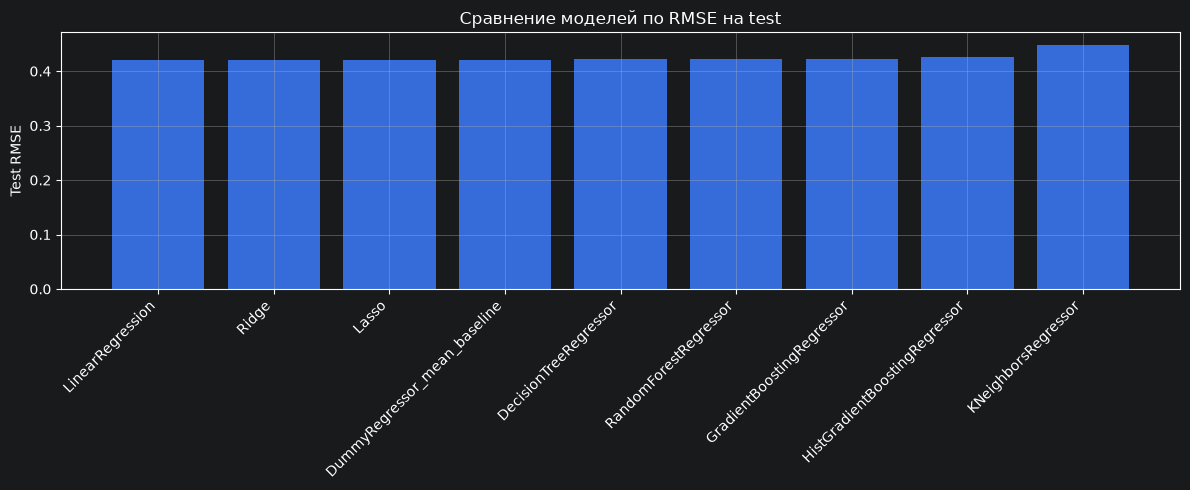

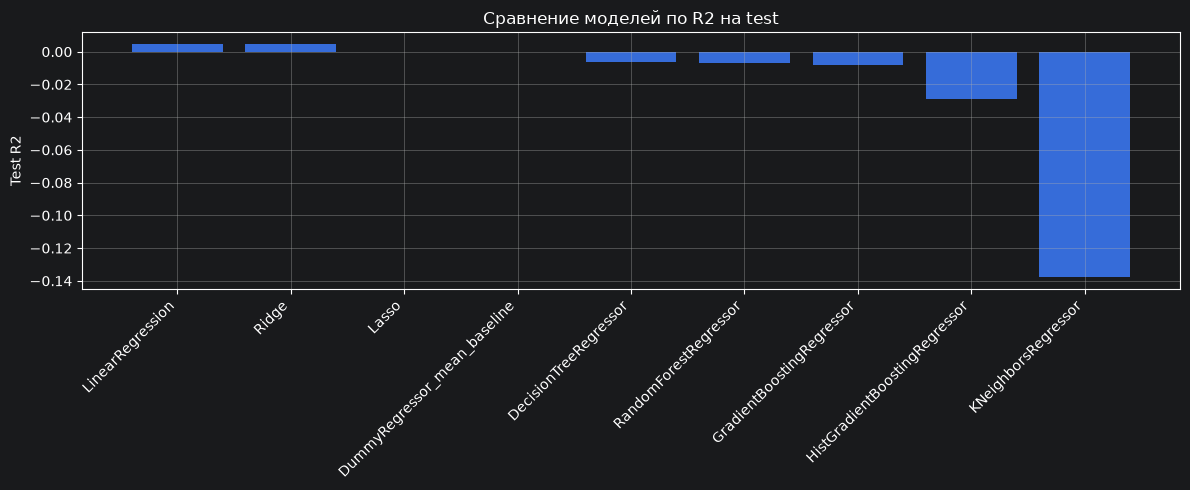

In [55]:
plt.figure(figsize=(12, 5))
plt.bar(full_results_df["model_name"], full_results_df["test_RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test RMSE")
plt.title("Сравнение моделей по RMSE на test")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(full_results_df["model_name"], full_results_df["test_R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test R2")
plt.title("Сравнение моделей по R2 на test")
plt.grid(True)
plt.tight_layout()
plt.show()

## 14. Факт vs прогноз

Смотрим, насколько прогнозы лучшей модели близки к фактическим значениям.

,y_true,y_pred,absolute_error
0,-0.2,-0.141854,0.058146
1,-0.3,-0.168368,0.131632
2,-0.6,-0.147661,0.452339
3,-0.5,-0.154155,0.345845
4,0.8,-0.169444,0.969444
5,-0.7,-0.101137,0.598863
6,-0.2,-0.199199,0.000801
7,0.0,-0.155254,0.155254
8,-0.2,-0.162636,0.037364
9,-0.2,-0.186141,0.013859


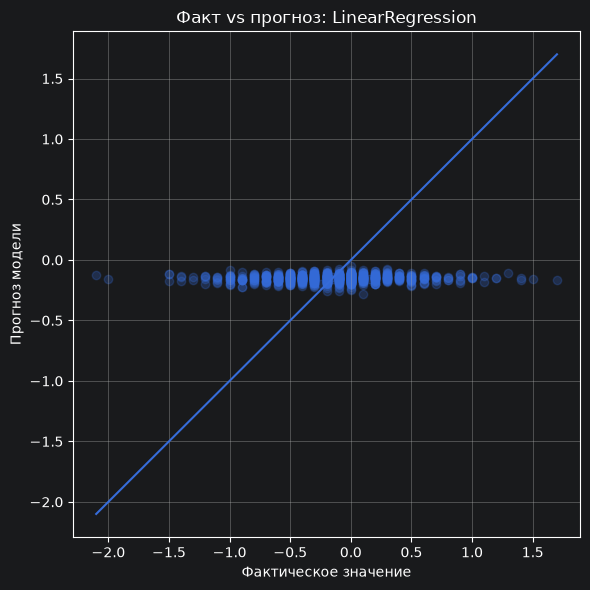

In [56]:
y_pred_best = best_model.predict(X_test)

prediction_check_df = pd.DataFrame(
    {
        "y_true": y_test.values,
        "y_pred": y_pred_best,
        "absolute_error": np.abs(y_test.values - y_pred_best),
    }
)

display(prediction_check_df.head(10))

plt.figure(figsize=(6, 6))
plt.scatter(prediction_check_df["y_true"],prediction_check_df["y_pred"], alpha=0.25)
plt.xlabel("Фактическое значение")
plt.ylabel("Прогноз модели")
plt.title(f"Факт vs прогноз: {best_model_name}")
plt.grid(True)

min_value = min(prediction_check_df["y_true"].min(), prediction_check_df["y_pred"].min())
max_value = max(prediction_check_df["y_true"].max(), prediction_check_df["y_pred"].max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.tight_layout()
plt.show()

## 15. Анализ крупнейших ошибок

Хороший ML-разработчик смотрит не только на среднюю метрику, но и на ошибки.

Вопросы для анализа:

- где модель ошиблась сильнее всего;
- похожи ли эти объекты на выбросы;
- каких признаков модели не хватает;
- можно ли улучшить датасет.

In [57]:
error_analysis_df = X_test.copy()
error_analysis_df["y_true"] = y_test.values
error_analysis_df["y_pred"] = y_pred_best
error_analysis_df["absolute_error"] = np.abs(error_analysis_df["y_true"] - error_analysis_df["y_pred"])

largest_errors_df = error_analysis_df.sort_values("absolute_error", ascending=False).head(10)
largest_errors_df

,energy_kcal,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g,y_true,y_pred,absolute_error
1501,3303.0,143.95,147.73,355.05,25.7,84.52,32.471,262.0,5896.0,2949.0,909.95,-2.1,-0.127905,1.972095
1351,3430.0,67.76,168.92,425.64,25.8,40.75,39.259,112.0,6474.0,2858.0,614.73,1.7,-0.162166,1.862166
3206,1201.0,72.68,54.96,111.54,25.7,34.11,8.711,21.0,2125.0,1332.0,438.37,-2.0,-0.160952,1.839048
5167,1789.0,54.10,92.22,197.01,14.9,5.08,32.586,114.0,2677.0,2301.0,344.01,1.5,-0.153872,1.653872
3827,2656.0,82.83,104.92,367.52,43.8,65.30,33.071,83.0,3495.0,2993.0,614.24,1.4,-0.161974,1.561974
1747,2084.0,99.23,78.63,247.01,22.4,85.95,21.545,175.0,5259.0,2978.0,835.38,1.4,-0.147573,1.547573
3388,2017.0,100.04,89.53,202.52,7.2,77.57,25.831,313.0,5781.0,1976.0,678.64,1.3,-0.107346,1.407346
1485,1456.0,105.17,36.10,188.63,25.5,5.00,15.107,109.0,893.0,1350.0,243.49,-1.5,-0.113891,1.386109
5138,1975.0,97.78,54.85,282.73,25.3,33.11,20.464,128.0,2298.0,2098.0,677.17,-1.5,-0.115123,1.384877
1034,3132.0,87.82,112.66,454.94,15.4,108.79,30.226,91.0,4635.0,1970.0,420.59,1.2,-0.150164,1.350164


## 16. Важность признаков, если модель это поддерживает

У деревьев и ансамблей деревьев часто есть `feature_importances_`.

Это помогает объяснить, какие признаки сильнее влияют на прогноз.

In [58]:
def get_feature_names_from_preprocessor(fitted_pipeline: Pipeline) -> list[str]:
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    feature_names = []

    if numeric_features:
        feature_names.extend(numeric_features)

    if categorical_features:
        cat_pipeline = fitted_preprocessor.named_transformers_["cat"]
        onehot = cat_pipeline.named_steps["onehot"]
        cat_names = onehot.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(cat_names)

    return feature_names

def show_feature_importance_if_available(fitted_pipeline: Pipeline, model_name: str):
    model = fitted_pipeline.named_steps["model"]

    if not hasattr(model, "feature_importances_"):
        print(f"У модели {model_name} нет feature_importances_.")
        return None

    feature_names = get_feature_names_from_preprocessor(fitted_pipeline)
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    return importance_df

importance_df = show_feature_importance_if_available(best_model, best_model_name)

if importance_df is not None:
    display(importance_df.head(15))

    top_importance = importance_df.head(15).sort_values("importance")

    plt.figure(figsize=(10, 5))
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.xlabel("Importance")
    plt.title(f"Важность признаков: {best_model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

У модели LinearRegression нет feature_importances_.


## 17. Прогноз для нового объекта

Новый объект должен иметь те же колонки, что и `X`.

In [59]:
new_object = pd.DataFrame(
    [
        {
            "energy_kcal":1418,
            "protein_g": 66,
            "fat_g":35,
            "carbohydrates_g":250,
            "fiber_g":20,
            "sugars_g":40,
            "saturated_fat_g": 10,
            "cholesterol_mg":0,
            "sodium_mg":3,
            "potassium_mg":1,
            "water_g":12,
        }
    ]
)

new_prediction = best_model.predict(new_object)

print("Прогноз стоимости жилья:", round(float(new_prediction[0]), 2))
display(new_object)

Прогноз стоимости жилья: -0.16


,energy_kcal,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g
0,1418,66,35,250,20,40,10,0,3,1,12


## 18. Сохраняем отчёты

Итоговые файлы можно использовать для защиты или дипломного проекта.

In [60]:
models_report_path = REPORTS_DIR / "models_comparison_report.csv"
errors_report_path = REPORTS_DIR / "largest_errors_report.csv"
predictions_report_path = REPORTS_DIR / "test_predictions_report.csv"
summary_report_path = REPORTS_DIR / "summary_report.md"

full_results_df.to_csv(models_report_path, index=False)
largest_errors_df.to_csv(errors_report_path, index=False)
prediction_check_df.to_csv(predictions_report_path, index=False)

summary_text = f'''# Отчёт факультативного ML-эксперимента

## Цель
Автоматически сравнить несколько моделей регрессии и выбрать модель с лучшим сопоставимым прогнозом.

## Целевая переменная
`{target_col}`

## Признаки
{feature_cols}

## Лучшая модель
`{best_model_name}`

## Качество лучшей модели на test
- MAE: {best_row["test_MAE"]:.2f}
- RMSE: {best_row["test_RMSE"]:.2f}
- R2: {best_row["test_R2"]:.4f}

## Вывод
Модель выбрана не на глаз, а через сопоставимый эксперимент:
один train/test split, одинаковые метрики, единый preprocessing pipeline и GridSearchCV.

## Ограничения
Результат зависит от датасета, признаков, набора моделей и сетки параметров.
Для диплома нужно отдельно описать предметную область, качество данных и практическую пользу прогноза.
'''

summary_report_path.write_text(summary_text, encoding="utf-8")

print("Файлы сохранены:")
print(models_report_path)
print(errors_report_path)
print(predictions_report_path)
print(summary_report_path)

Файлы сохранены:
..\..\reports\models_comparison_report.csv
..\..\reports\largest_errors_report.csv
..\..\reports\test_predictions_report.csv
..\..\reports\summary_report.md


## 19. Как объяснить на защите

Можно сказать так:

> Я сделал учебный AutoML-подход.  
> Я не выбирал модель вручную, а сравнил несколько моделей на одном датасете.  
> Для честности использовал один train/test split, единый preprocessing pipeline, одинаковые метрики и GridSearchCV.  
> В качестве baseline использовал DummyRegressor.  
> Лучшую модель выбрал по минимальному RMSE на test.  
> После этого проверил ошибки, построил графики и сделал прогноз для нового объекта.

Это уже ближе к реальной работе ML-разработчика: не просто обучить одну модель, а организовать проверяемый эксперимент.

## 20. Как адаптировать под диплом

Для своего диплома студент меняет:

1. `DATA_URL` или способ загрузки данных.
2. `target_column`.
3. `feature_columns`.
4. Набор моделей.
5. Метрики.
6. Текст отчёта.

Примеры:

**Питание**  
Прогноз калорийности, сахара, белка, рейтинга полезности.

**Финансовый анализ**  
Прогноз расходов, цены, доходности, риска.

**Вовлечённость в мероприятия**  
Прогноз посещаемости, оценки мероприятия, активности участника.

## 21. Контрольные вопросы

1. Почему нельзя выбирать модель только по train score?
2. Зачем нужен baseline?
3. Почему preprocessing должен быть внутри pipeline?
4. Что такое data leakage?
5. Почему лучшая модель в одном эксперименте может не быть лучшей в другом?
6. Что означает RMSE?
7. Почему важно смотреть крупные ошибки?
8. Как этот подход применить в дипломе?

In [62]:
assert isinstance(full_results_df, pd.DataFrame)
assert len(full_results_df) >= 2
assert "test_RMSE" in full_results_df.columns
assert best_model_name in model_configs.keys()
assert prediction_check_df.shape[0] == X_test.shape[0]
assert models_report_path.exists()
assert summary_report_path.exists()

print("Все финальные проверки пройдены.")
print("Лучшая модель:", best_model_name)
print("Файл отчёта:", summary_report_path)

Все финальные проверки пройдены.
Лучшая модель: LinearRegression
Файл отчёта: ..\..\reports\summary_report.md
